In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tracks2026.csv")
df_original = df #Safety measure for manipulation of data
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


Reviewing the document for Exploritory Data Analysis recommends Log Transformation and Standard Scaler for acousticness and valence, and Log Transfer for Robust Scaler for all other columns, I will set up and apply those to the data

In [3]:
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define column groups
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'popularity', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

preprocess_outliers = Pipeline([
    ('scaler', RobustScaler())  # Removed log to avoid issues with negative values like loudness
])

# Combined preprocessor (will be fitted separately for each dataset)
preprocessor = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers', preprocess_outliers, outlier_cols),
        ('passthrough', 'passthrough', passthrough_cols)
    ]
)

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nPercentage of missing values: {df.isnull().sum().sum() / len(df) * 100:.2f}%")

# Also check info
print("\nDataFrame info:")
df.info()

Missing values per column:
track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

Total missing values: 199

Percentage of missing values: 9.95%

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          2000 non-null   object 
 1   popularity        1960 non-null   float64
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   

According to EDA valance, popularity and aucusticness don't have outliers

In [5]:
# Identify columns with outliers (excluding valence, popularity, acousticness)
outlier_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['valence', 'popularity', 'acousticness']]

# Function to detect outliers using IQR
def is_outlier(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# Create a mask for rows with outliers in any of the outlier_columns
outlier_mask = df[outlier_columns].apply(is_outlier).any(axis=1)

# Split the dataset
df_without_outliers = df[~outlier_mask]
df_with_outliers = df[outlier_mask]

print(f"Original dataset size: {len(df)}")
print(f"Dataset without outliers: {len(df_without_outliers)}")
print(f"Dataset with outliers: {len(df_with_outliers)}")

# Check min values for no_outlier_cols
print("Min values for no_outlier_cols:")
print(df[['valence', 'popularity', 'acousticness']].min())

Original dataset size: 2000
Dataset without outliers: 1112
Dataset with outliers: 888
Min values for no_outlier_cols:
valence         0.035900
popularity      0.000000
acousticness    0.000007
dtype: float64


In [6]:
# Apply preprocessing to the datasets
# Fit and transform separately for each dataset to ensure proper scaling

df_without_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_without_outliers),
    columns=df.columns
)

df_with_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_with_outliers),
    columns=df.columns
)

# Now df_without_outliers_transformed and df_with_outliers_transformed are preprocessed

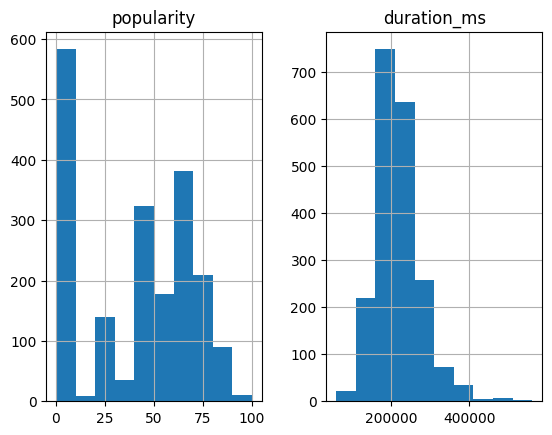

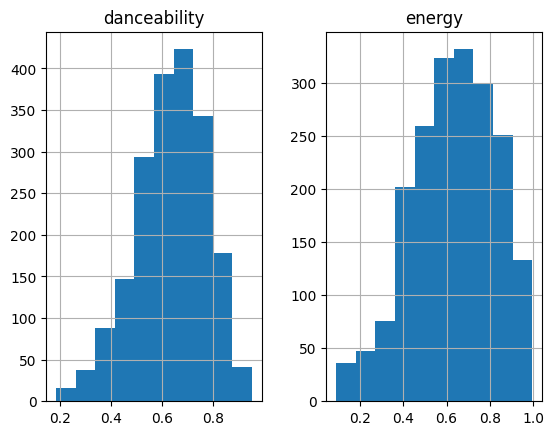

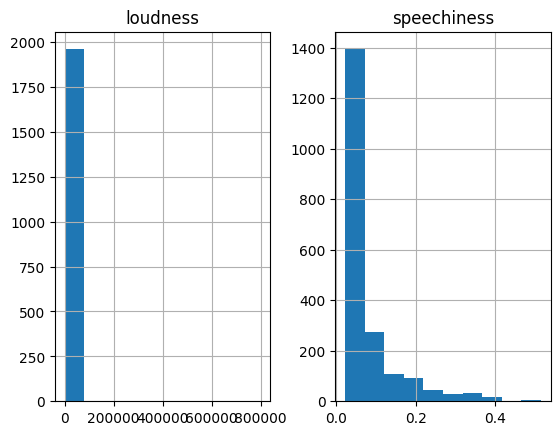

In [7]:
df[['popularity','duration_ms']].hist()
plt.show()
df[['danceability', 'energy']].hist()
plt.show()
df[['loudness', 'speechiness']].hist()
plt.show()